### **Задание**: *Построение базовой нейронной сети для классификации  изображений*
* Будем использовать библиотеку PyTorch и датасет MNIST
* Построим базовую полносвязную нейронную сеть с небольшим количеством слоёв

In [2]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns

### Определим преобразователь данных: `transforms.ToTensor()` преобразует данные в тензор, а `.Normalize()` нормализует данные

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

### Загружаем тренировочный и тестовый датасеты MNIST из `torchvision.datasets`

In [4]:
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

### Определяем `DataLoader`'ы, позволяющие итерироваться по батчам данных.

In [5]:
train_loader = DataLoader(dataset=train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=32, shuffle=True)

### **Опишем архитектуру нашей нейронной сети:**
#### **Входные данные**: изображения цифр 28x28, представленные в виде одномерного массива длиной 784
#### **Тип сети**: Полносвязная нейронная сеть
#### **Структура сети**:
1. **Входной слой**(`nn.Flatten()`): 784 нейрона

2. **Скрытый слой**(`nn.Linear(28*28, 128)`): 128 нейронов

   **_Функция активации_**: ReLU(`nn.ReLU`) 
    
3. **Выходной слой**(`nn.Linear(128, 10)`): 10 нейронов

   **_Функция активации_**: Softmax.
 

In [6]:
import torch.nn as nn


class MnistClassificationNN(nn.Module):
    def __init__(self):
        super(MnistClassificationNN, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

In [7]:
model = MnistClassificationNN()
print(model)

MnistClassificationNN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [18]:
import torch.optim as optim
from tqdm import tqdm

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


def train_model(model, train_loader, criterion, optimizer, epochs=10):
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        correct = 0
        total = 0

        progress_bar = tqdm(train_loader, desc=f'Epoch {epoch + 1}/{epochs}')
        for images, labels in progress_bar:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            progress_bar.set_postfix(loss=running_loss / len(test_loader), accuracy=100 * correct / total)

In [19]:
train_model(model, train_loader, criterion, optimizer)

Epoch 10/10: 100%|██████████| 1875/1875 [00:14<00:00, 130.38it/s, accuracy=99, loss=0.176]   


In [20]:
from sklearn.metrics import classification_report, confusion_matrix


def evaluate_model(model, test_loader):
    model.eval()
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_labels.extend(labels.cpu().numpy().tolist())
            all_preds.extend(predicted.cpu().numpy().tolist())

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

    report = classification_report(all_labels, all_preds, target_names=test_loader.dataset.classes)
    print("Classification Report:\n", report)


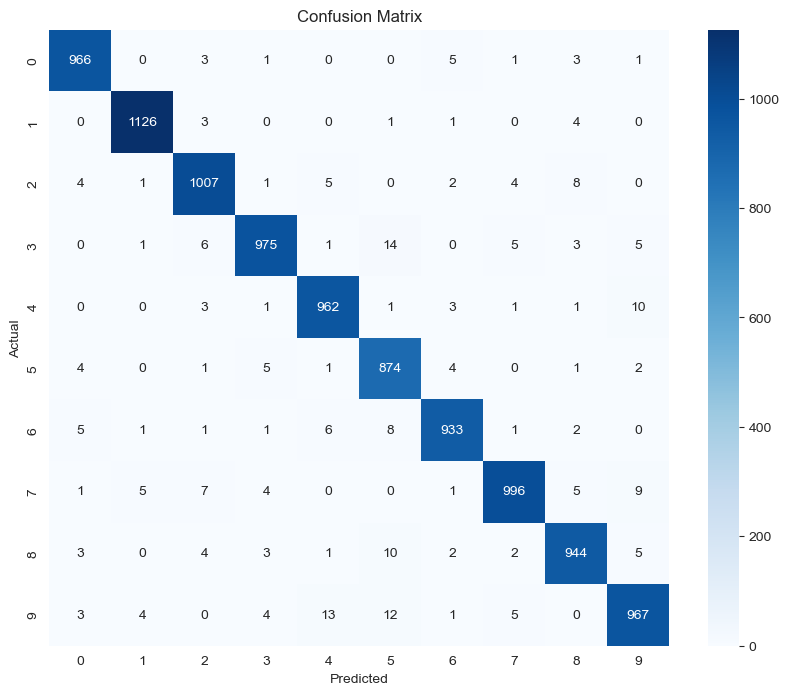

Classification Report:
               precision    recall  f1-score   support

    0 - zero       0.98      0.99      0.98       980
     1 - one       0.99      0.99      0.99      1135
     2 - two       0.97      0.98      0.97      1032
   3 - three       0.98      0.97      0.97      1010
    4 - four       0.97      0.98      0.98       982
    5 - five       0.95      0.98      0.96       892
     6 - six       0.98      0.97      0.98       958
   7 - seven       0.98      0.97      0.98      1028
   8 - eight       0.97      0.97      0.97       974
    9 - nine       0.97      0.96      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.98      0.97      0.98     10000



In [40]:
evaluate_model(model, test_loader)

In [33]:
def plot_images(model, test_loader):
    model.eval()
    correct_examples = []
    incorrect_examples = []

    with torch.no_grad(): 
        for images, labels in test_loader:
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            correct_mask = (predicted == labels)
            incorrect_mask = (predicted != labels)
            for img, true_label, pred_label in zip(images[correct_mask], labels[correct_mask], predicted[correct_mask]):
                if len(correct_examples) < 5:
                    correct_examples.append((img.squeeze().numpy(), true_label.item(), pred_label.item()))
                else:
                    break
            for img, true_label, pred_label in zip(images[incorrect_mask], labels[incorrect_mask], predicted[incorrect_mask]):
                if len(incorrect_examples) < 5:
                    incorrect_examples.append((img.squeeze().numpy(), true_label.item(), pred_label.item()))
                else:
                    break
            if len(correct_examples) >= 5 and len(incorrect_examples) >= 5:
                break
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for i, ax in enumerate(axes.flat[:len(correct_examples)]):
        img, true_label, pred_label = correct_examples[i]
        ax.imshow(img, cmap='gray')
        ax.set_title(f"True: {true_label}\nPred: {pred_label}")
        ax.axis('off')
    for i, ax in enumerate(axes.flat[5:5 + len(incorrect_examples)]):
        img, true_label, pred_label = incorrect_examples[i]
        ax.imshow(img, cmap='gray')
        ax.set_title(f"True: {true_label}\nPred: {pred_label}", color='red')
        ax.axis('off')
    for ax in axes.flat[len(correct_examples) + len(incorrect_examples):]:
        ax.axis('off')
    plt.suptitle("Classification Examples")
    plt.show()

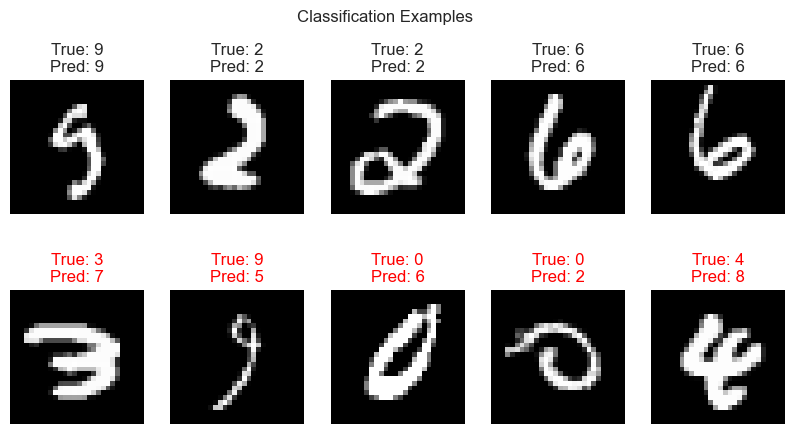

In [39]:
plot_images(model, test_loader)